# data4simplace — output QA & visualization

Checks and visualizes the SIMPLACE input files produced by
`data4simplace --config config.yaml`:

- **Soil** — `output/soil/soil.csv` (wide, one row per 10 km cell, 6 depth layers),
  built via the dominant-soil-type 250 m workflow (`dominant_mode: usda`).
- **Weather** — `output/weather/daily_mean_RES1_C*R*.csv.gz` (one per cropland cell).

The pipeline masks the grid to CORINE cropland, so only a subset of the full
Brandenburg grid is exported. Cells are keyed by `SimplaceID` (soil `location`)
and by `C_<col>:R_<row>` (weather `Gridcell`); we join both back to lat/lon via
the reproducible target grid.

## 1. Setup & grid lookup

In [2]:
import glob, gzip, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data4simplace
from data4simplace.config import load_config
from data4simplace.grid import TargetGrid

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

REPO = Path(data4simplace.__file__).resolve().parents[2]
OUT = REPO / "output"
cfg = load_config(REPO / "config.yaml")
grid = TargetGrid.from_config(cfg.grid)
cells = grid.cell_table()  # SimplaceID, row, col, lat, lon over the FULL grid
MISSING = cfg.missing_value
print("Grid:", grid.shape, "cells | resolution", grid.resolution_deg, "deg")
print("dominant_mode:", cfg.soil.dominant_mode, "| cropland_min_fraction:", cfg.soil.cropland_min_fraction)
cells.head()

Grid: (380, 690) cells | resolution 0.1 deg
dominant_mode: usda | cropland_min_fraction: 0.8


,SimplaceID,row,col,lat,lon
0,1,0,0,71.95,-16.95
1,2,0,1,71.95,-16.85
2,3,0,2,71.95,-16.75
3,4,0,3,71.95,-16.65
4,5,0,4,71.95,-16.55


## 2. Soil profile file

`soil.csv` is the SIMPLACE wide layout: single-value profile attributes plus
per-layer `<stem>_<N>` columns for N = 1..6 depth layers. We reshape the
SoilGrids-derived stems to long form and join lat/lon via `location`.

In [3]:
soil = pd.read_csv(OUT / "soil" / "soil.csv")
print("soil.csv:", soil.shape, "| unique locations:", soil['location'].nunique())

# Per-layer stems we care about (derived from SoilGrids / PTF).
STEMS = ["clay", "sand", "carbon", "PH", "bulkdensity",
         "soilwater_fc", "soilwater_wp", "soilwater_sat"]
LAYER_BOTTOMS_CM = [5, 15, 30, 60, 100, 200]

def to_long(df, stems):
    recs = []
    for _, r in df.iterrows():
        for n in range(1, 7):
            rec = {"location": int(r["location"]), "layer": n,
                   "bottom_cm": LAYER_BOTTOMS_CM[n-1]}
            for st in stems:
                col = f"{st}_{n}"
                rec[st] = r[col] if col in df.columns else np.nan
            recs.append(rec)
    return pd.DataFrame.from_records(recs)

long = to_long(soil, STEMS)
long = long.merge(cells[["SimplaceID", "row", "col", "lat", "lon"]],
                  left_on="location", right_on="SimplaceID", how="left")
# Treat SIMPLACE missing sentinels as NaN for analysis.
for st in STEMS:
    long.loc[long[st] <= MISSING + 1e-6, st] = np.nan
long.head()

soil.csv: (504, 142) | unique locations: 504


,location,layer,bottom_cm,clay,sand,carbon,PH,bulkdensity,soilwater_fc,soilwater_wp,soilwater_sat,SimplaceID,row,col,lat,lon
0,1,1,5,12.39423,59.52671,42.14522,6.03336,1.33230,0.285640,0.131925,0.532820,1,0,0,71.95,-16.95
1,1,2,15,12.57957,59.04258,20.71836,6.16245,1.46918,0.319272,0.171372,0.527525,1,0,0,71.95,-16.95
2,1,3,30,16.17815,56.45469,12.36963,6.46476,1.56653,0.325613,0.170681,0.525815,1,0,0,71.95,-16.95
3,1,4,60,16.71289,56.12089,10.58967,6.53564,1.58726,0.280413,0.140449,0.497768,1,0,0,71.95,-16.95
4,1,5,100,17.24764,55.78710,8.80971,6.60652,1.60800,0.312107,0.164181,0.512156,1,0,0,71.95,-16.95


### 2.1 Coverage & missing-value audit

In [4]:
n_grid = len(cells)
n_soil = soil['location'].nunique()
print(f"Exported soil cells: {n_soil} / {n_grid} full-grid cells "
      f"({100*n_soil/n_grid:.1f}% kept by cropland mask)")

# Per-stem valid fraction across all cell-layers.
audit = (long[STEMS].notna().mean() * 100).round(1).rename("valid_%").to_frame()
audit["min"] = long[STEMS].min().round(3)
audit["max"] = long[STEMS].max().round(3)
audit["mean"] = long[STEMS].mean().round(3)
audit

Exported soil cells: 504 / 262200 full-grid cells (0.2% kept by cropland mask)


,valid_%,min,max,mean
clay,100.0,5.930,36.026,16.683
sand,100.0,9.395,83.493,58.792
carbon,100.0,2.489,48.703,15.606
PH,100.0,5.624,7.318,6.688
bulkdensity,100.0,1.232,1.702,1.540
soilwater_fc,100.0,0.280,0.326,0.306
soilwater_wp,100.0,0.132,0.171,0.157
soilwater_sat,100.0,0.498,0.533,0.518


### 2.2 Topsoil property maps (layer 1, 0–5 cm)

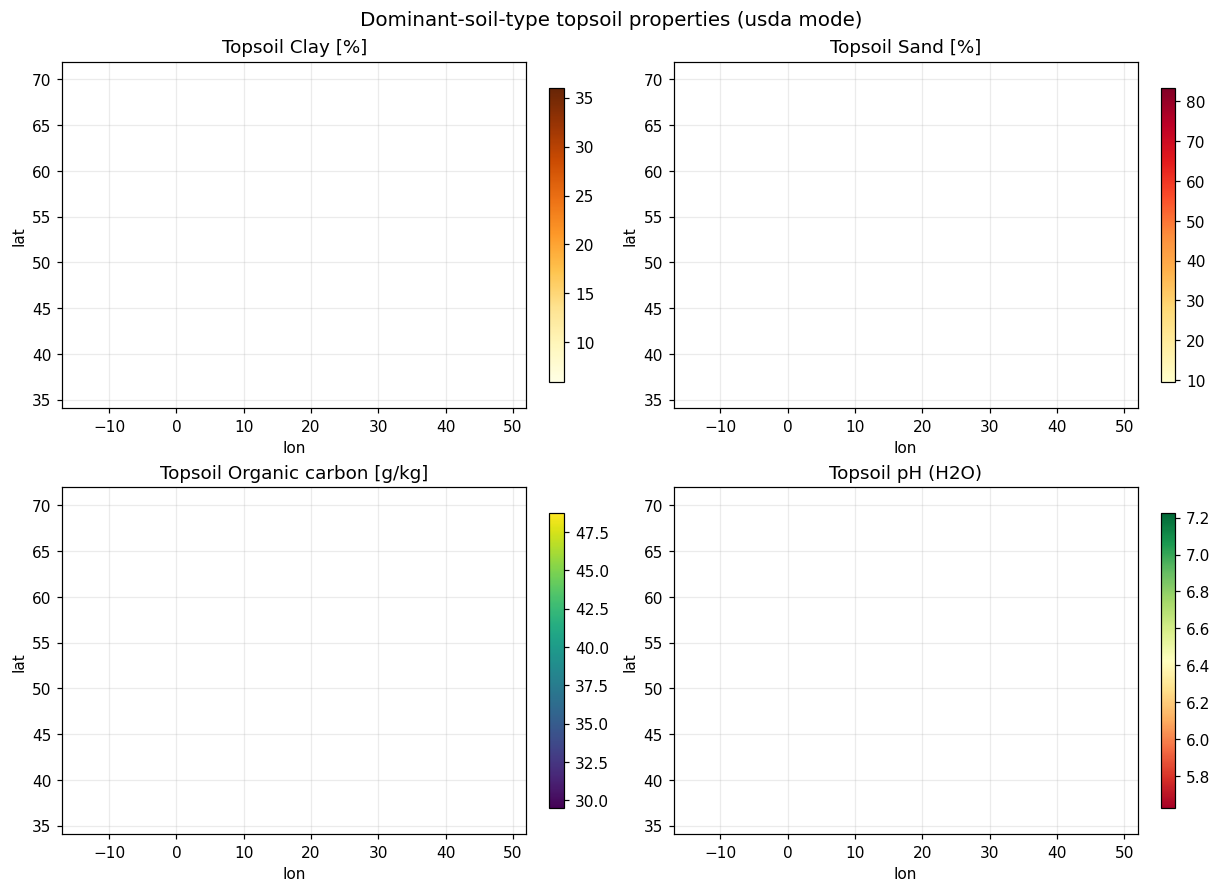

In [5]:
def grid_image(df, value, row="row", col="col"):
    img = np.full(grid.shape, np.nan)
    img[df[row].astype(int), df[col].astype(int)] = df[value].values
    return img

top = long[long.layer == 1]
extent = [grid.lon_centers.min(), grid.lon_centers.max(),
          grid.lat_centers.min(), grid.lat_centers.max()]
panels = [("clay", "Clay [%]", "YlOrBr"), ("sand", "Sand [%]", "YlOrRd"),
          ("carbon", "Organic carbon [g/kg]", "viridis"), ("PH", "pH (H2O)", "RdYlGn")]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, (var, title, cmap) in zip(axes.ravel(), panels):
    im = ax.imshow(grid_image(top, var), extent=extent, origin="upper",
                   cmap=cmap, aspect="auto")
    ax.set_title(f"Topsoil {title}")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle("Dominant-soil-type topsoil properties (usda mode)", fontsize=13)
plt.show()

### 2.3 Depth profiles (domain mean ± IQR)

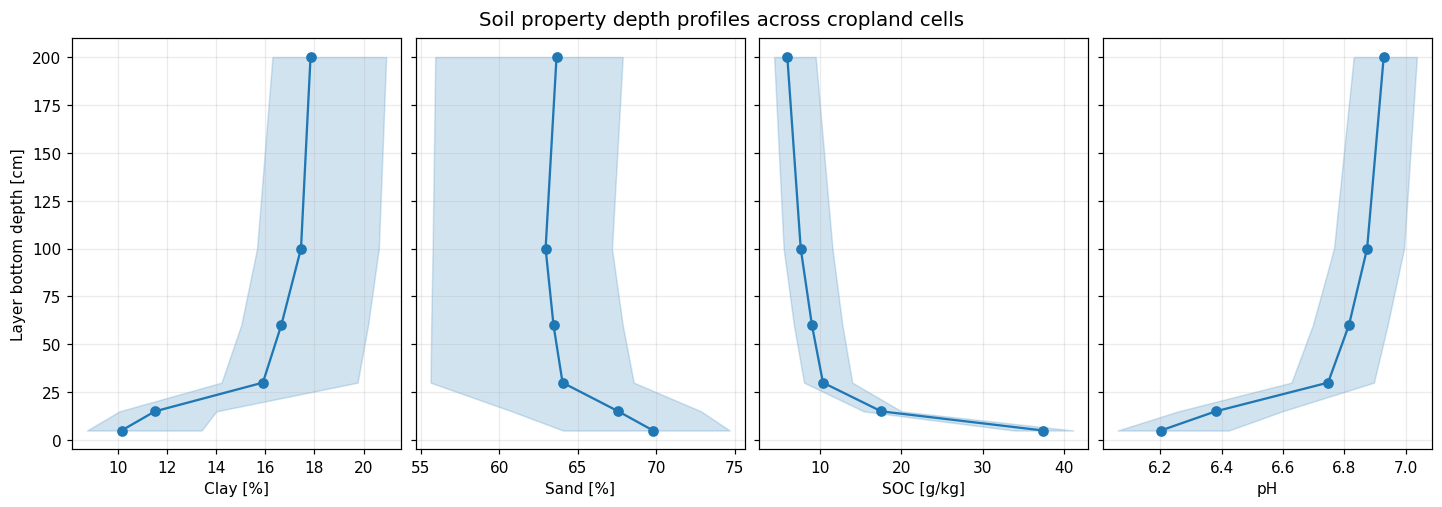

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5), sharey=True, constrained_layout=True)
prof_vars = [("clay", "Clay [%]"), ("sand", "Sand [%]"),
             ("carbon", "SOC [g/kg]"), ("PH", "pH")]
depths = np.array(LAYER_BOTTOMS_CM)
for ax, (var, title) in zip(axes, prof_vars):
    g = long.groupby("layer")[var]
    med = g.median().values; q1 = g.quantile(.25).values; q3 = g.quantile(.75).values
    ax.plot(med, depths, "-o", color="tab:blue")
    ax.fill_betweenx(depths, q1, q3, alpha=0.2, color="tab:blue")
    ax.set_xlabel(title); ax.invert_yaxis()
axes[0].set_ylabel("Layer bottom depth [cm]")
fig.suptitle("Soil property depth profiles across cropland cells", fontsize=13)
plt.show()

### 2.4 Texture sanity check

The 250 m workflow re-normalizes texture so `clay + silt + sand = 100 %` before
export. `soil.csv` stores clay and sand; the implied silt is `100 − clay − sand`
and must be in `[0, 100]`.

clay+sand range: [36.33, 91.26]
implied silt range: [8.74, 63.67]
cell-layers with implied silt < 0: 0 (should be 0)


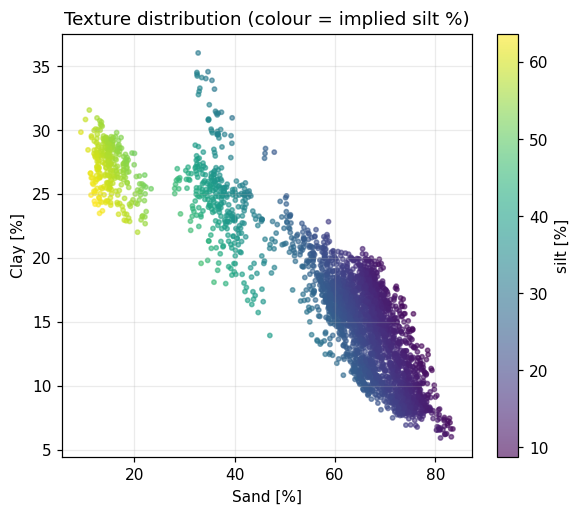

In [7]:
tex = long.dropna(subset=["clay", "sand"]).copy()
tex["silt_implied"] = 100 - tex["clay"] - tex["sand"]
print("clay+sand range: [%.2f, %.2f]" % (
    (tex.clay + tex.sand).min(), (tex.clay + tex.sand).max()))
print("implied silt range: [%.2f, %.2f]" % (tex.silt_implied.min(), tex.silt_implied.max()))
neg = (tex.silt_implied < -0.5).sum()
print("cell-layers with implied silt < 0:", neg, "(should be 0)")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(tex.sand, tex.clay, c=tex.silt_implied, cmap="viridis", s=8, alpha=0.6)
ax.set_xlabel("Sand [%]"); ax.set_ylabel("Clay [%]")
ax.set_title("Texture distribution (colour = implied silt %)")
fig.colorbar(sc, ax=ax, label="silt [%]"); plt.show()

### 2.5 Aggregation check — clay vs cropland

The dominant-soil-type aggregation only produces values where the 250 m stack had
cropland pixels (PROBA-V cover ≥ `cropland_min_fraction`). So exported clay must
sit **exactly** on cropland cells and never leak onto non-cropland. We compare the
aggregated topsoil clay against the PROBA-V cropland cover fraction re-gridded to
10 km, and check for any leakage.

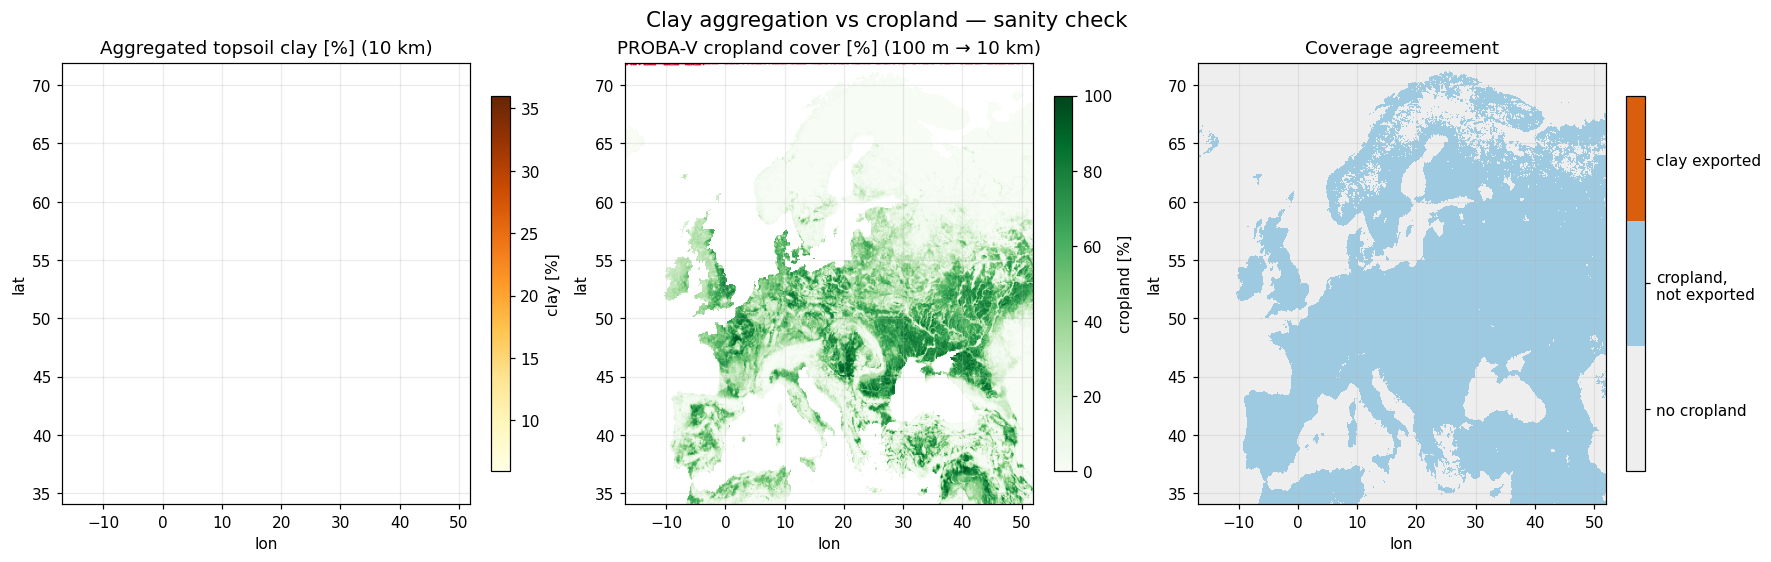

clay-exported cells: 504
  with cropland > 0 : 0 (0.0%)
  leak (clay where cropland == 0): 504  (should be 0)
corr(clay, cropland cover) over exported cells: +nan


In [8]:
from data4simplace.spatial.cropland_weights import CroplandWeights
from matplotlib.colors import ListedColormap

clay_img = grid_image(top, "clay")
clay_present = np.isfinite(clay_img)

# PROBA-V cropland cover (100 m, 0-1) aggregated to the 10 km grid, in %.
frac = CroplandWeights(cfg).load_fraction()
crop_img = (grid.regrid(frac, method="mean") * 100.0).reindex(
    lat=grid.lat_centers, lon=grid.lon_centers).values
crop_any = np.isfinite(crop_img) & (crop_img > 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
im0 = axes[0].imshow(clay_img, extent=extent, origin="upper", cmap="YlOrBr", aspect="auto")
axes[0].set_title("Aggregated topsoil clay [%] (10 km)")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="clay [%]")

im1 = axes[1].imshow(crop_img, extent=extent, origin="upper", cmap="Greens",
                     aspect="auto", vmin=0, vmax=100)
axes[1].set_title("PROBA-V cropland cover [%] (100 m → 10 km)")
axes[1].contour(clay_present.astype(float), levels=[0.5], colors="crimson",
                linewidths=0.8, extent=extent, origin="upper")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label="cropland [%]")

cat = np.where(clay_present, 2, np.where(crop_any, 1, 0))
cmap = ListedColormap(["#eeeeee", "#9ecae1", "#d95f0e"])
im2 = axes[2].imshow(cat, extent=extent, origin="upper", cmap=cmap, aspect="auto",
                     vmin=0, vmax=2)
axes[2].set_title("Coverage agreement")
cb = fig.colorbar(im2, ax=axes[2], shrink=0.85, ticks=[0.33, 1.0, 1.66])
cb.ax.set_yticklabels(["no cropland", "cropland,\nnot exported", "clay exported"])
for ax in axes:
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.suptitle("Clay aggregation vs cropland — sanity check", fontsize=14)
plt.show()

leak = int((clay_present & ~crop_any).sum())
flat_crop = crop_img[clay_present]
print(f"clay-exported cells: {int(clay_present.sum())}")
print(f"  with cropland > 0 : {int((flat_crop > 0).sum())} "
      f"({100*(flat_crop > 0).mean():.1f}%)")
print(f"  leak (clay where cropland == 0): {leak}  (should be 0)")
print(f"corr(clay, cropland cover) over exported cells: "
      f"{np.corrcoef(clay_img[clay_present], flat_crop)[0,1]:+.3f}")

### 2.6 SOC & pH vs the dominant soil class

The 250 m workflow picks **one dominant USDA texture class per 10 km cell**
(majority vote over cropland-filtered pixels) and aggregates only pixels of that
class — so the exported SOC and pH are properties *of that class*, not of the
whole cell. Here we put the three maps side by side and quantify how much of the
between-cell spread the class alone explains (`eta^2` = between-class share of
variance).

The class label itself is not written to `soil.csv`, so we reconstruct it by
running the package's own `usda_texture_class` on the exported topsoil texture
(`silt = 100 − clay − sand`). This recovers the selection class exactly wherever
the aggregate stays inside the class polygon — true for cropland-weighted means
of same-class pixels, since the USDA polygons are convex — except in
nearest-neighbour gap-filled cells, which inherit a neighbour's values.


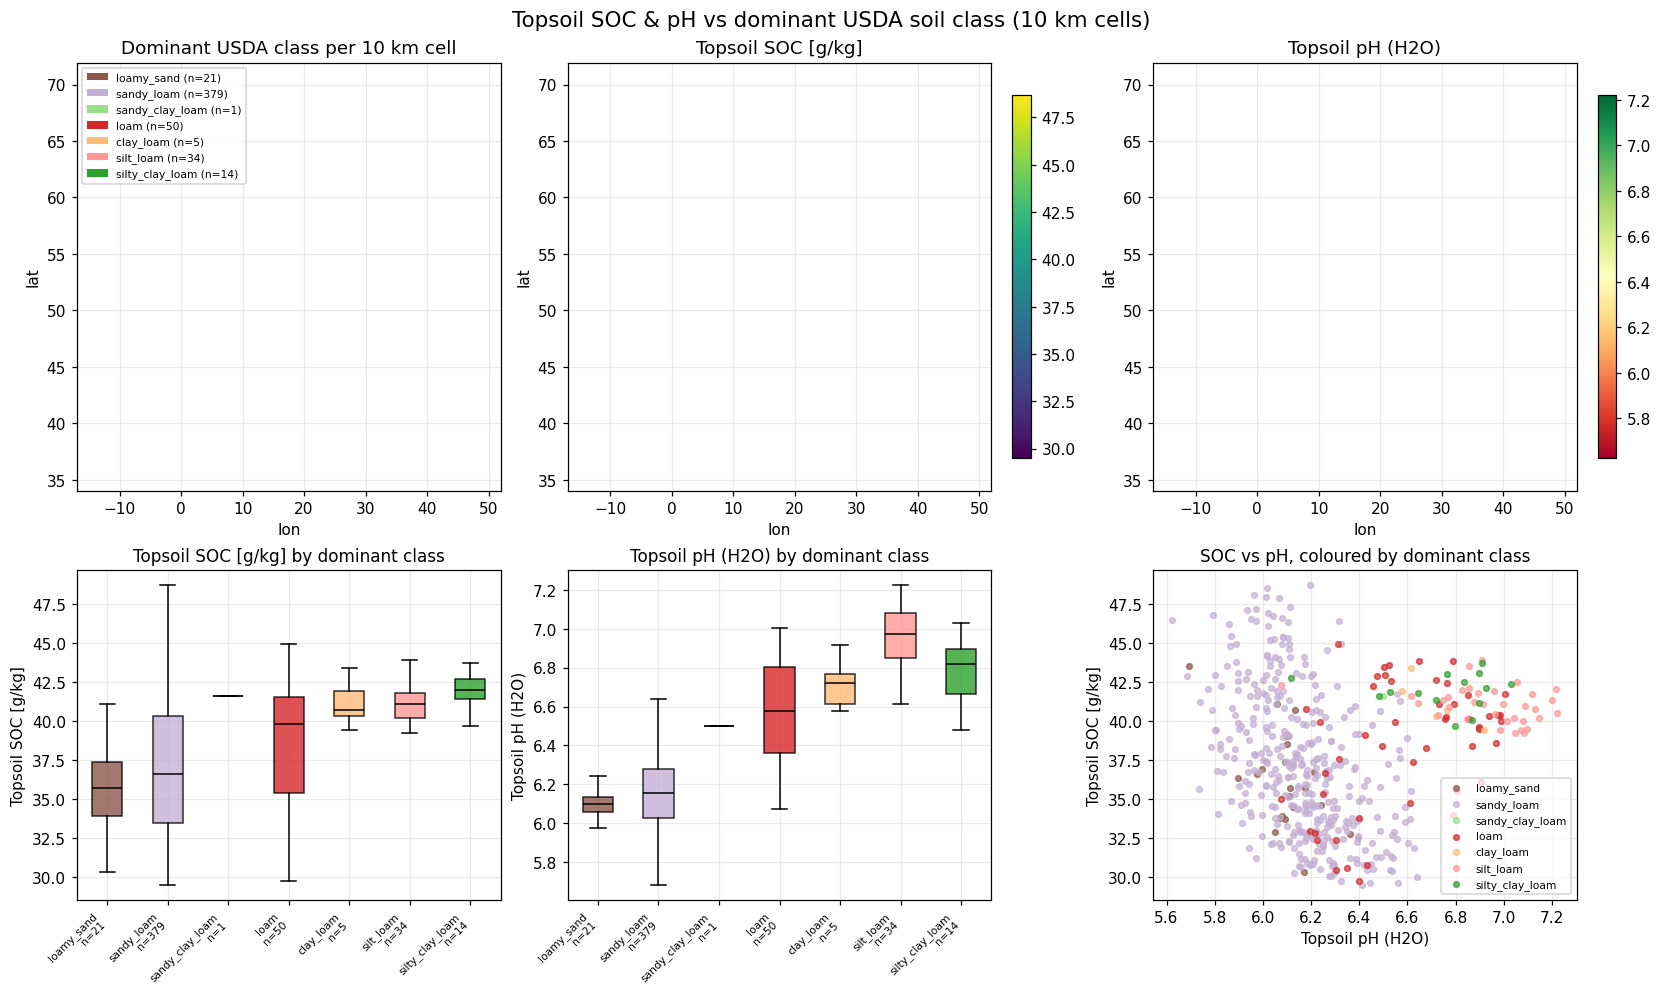

                 cells   clay   sand  SOC_median  SOC_sd  pH_median  pH_sd
usda_name                                                                 
sandy_loam         379   9.99  71.00       36.59    4.60       6.16   0.20
loam                50  21.11  40.56       39.79    4.10       6.58   0.27
silt_loam           34  24.65  16.30       41.10    1.16       6.97   0.22
loamy_sand          21   6.91  81.45       35.70    3.13       6.10   0.13
silty_clay_loam     14  29.84  13.07       41.98    1.13       6.82   0.24
clay_loam            5  32.19  34.53       40.72    1.54       6.72   0.14
sandy_clay_loam      1  24.71  50.17       41.61     NaN       6.50    NaN

variance explained by dominant class: SOC eta^2 = 0.091 | pH eta^2 = 0.585


In [9]:
import xarray as xr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from data4simplace.soil.dominant import USDA_CLASSES, usda_texture_class

# The dominant class is an internal pipeline product, so rebuild it per cell from
# the exported topsoil texture (silt = 100 - clay - sand after normalization).
# USDA polygons are convex, so the weighted mean of same-class 250 m pixels falls
# back inside the class those pixels were selected by.
dom = top.dropna(subset=["clay", "sand"]).copy()
dom["silt"] = (100 - dom["clay"] - dom["sand"]).clip(lower=0)
as_da = lambda s: xr.DataArray(s.to_numpy(), dims="cell")  # noqa: E731
dom["usda"] = usda_texture_class(as_da(dom.sand), as_da(dom.silt), as_da(dom.clay)).values
dom["usda_name"] = dom["usda"].map(USDA_CLASSES)

counts = dom["usda"].value_counts()
# Order classes coarse -> fine (mean sand descending) so the panels read as a gradient.
order = list(dom.groupby("usda")["sand"].mean().sort_values(ascending=False).index)
tab20 = plt.get_cmap("tab20")
cmap_cls = ListedColormap([tab20((c - 1) % 20) for c in order])
idx_of = {c: i for i, c in enumerate(order)}
dom["cls_idx"] = dom["usda"].map(idx_of)

fig = plt.figure(figsize=(15, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1])
maps = []

ax = fig.add_subplot(gs[0, 0]); maps.append(ax)
ax.imshow(grid_image(dom, "cls_idx"), extent=extent, origin="upper", cmap=cmap_cls,
          vmin=-0.5, vmax=len(order) - 0.5, aspect="auto", interpolation="nearest")
ax.set_title("Dominant USDA class per 10 km cell")
ax.legend(handles=[Patch(facecolor=cmap_cls(i), label=f"{USDA_CLASSES[c]} (n={counts[c]})")
                   for i, c in enumerate(order)],
          fontsize=7, loc="upper left", framealpha=0.85)

for j, (var, title, cmap) in enumerate(
        [("carbon", "Topsoil SOC [g/kg]", "viridis"),
         ("PH", "Topsoil pH (H2O)", "RdYlGn")], start=1):
    axm = fig.add_subplot(gs[0, j]); maps.append(axm)
    im = axm.imshow(grid_image(dom, var), extent=extent, origin="upper",
                    cmap=cmap, aspect="auto")
    axm.set_title(title)
    fig.colorbar(im, ax=axm, shrink=0.85)
for axm in maps:
    axm.set_xlabel("lon"); axm.set_ylabel("lat")

# Distribution of each property within each dominant class.
labels = [f"{USDA_CLASSES[c]}\nn={counts[c]}" for c in order]
for j, (var, title) in enumerate([("carbon", "Topsoil SOC [g/kg]"),
                                  ("PH", "Topsoil pH (H2O)")]):
    axb = fig.add_subplot(gs[1, j])
    bp = axb.boxplot([dom.loc[dom.usda == c, var].dropna().values for c in order],
                     patch_artist=True, showfliers=False, medianprops={"color": "black"})
    for patch, c in zip(bp["boxes"], order):
        patch.set_facecolor(cmap_cls(idx_of[c])); patch.set_alpha(0.8)
    axb.set_title(f"{title} by dominant class", fontsize=11)
    axb.set_ylabel(title)
    axb.set_xticks(range(1, len(order) + 1))
    axb.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")

axs = fig.add_subplot(gs[1, 2])
for c in order:
    sub = dom[dom.usda == c]
    axs.scatter(sub.PH, sub.carbon, s=14, alpha=0.7, color=cmap_cls(idx_of[c]),
                label=USDA_CLASSES[c])
axs.set_xlabel("Topsoil pH (H2O)"); axs.set_ylabel("Topsoil SOC [g/kg]")
axs.set_title("SOC vs pH, coloured by dominant class", fontsize=11)
axs.legend(fontsize=7, loc="best")

fig.suptitle("Topsoil SOC & pH vs dominant USDA soil class (10 km cells)", fontsize=14)
plt.show()


def eta_squared(values, groups):
    """Share of between-cell variance explained by the dominant class."""
    v = np.asarray(values, float); g = np.asarray(groups)
    ok = np.isfinite(v); v, g = v[ok], g[ok]
    ss_tot = ((v - v.mean()) ** 2).sum()
    ss_bet = sum(len(v[g == k]) * (v[g == k].mean() - v.mean()) ** 2 for k in np.unique(g))
    return ss_bet / ss_tot if ss_tot > 0 else np.nan


summary = (dom.groupby("usda_name")
             .agg(cells=("location", "size"), clay=("clay", "mean"), sand=("sand", "mean"),
                  SOC_median=("carbon", "median"), SOC_sd=("carbon", "std"),
                  pH_median=("PH", "median"), pH_sd=("PH", "std"))
             .round(2).sort_values("cells", ascending=False))
print(summary.to_string())
print(f"\nvariance explained by dominant class: "
      f"SOC eta^2 = {eta_squared(dom.carbon, dom.usda):.3f} | "
      f"pH eta^2 = {eta_squared(dom.PH, dom.usda):.3f}")

## 3. Weather files

Each cropland cell has a gzipped, **tab-separated** daily file. `Gridcell` encodes
`C_<col>:R_<row>`; unset variables use the `-99.9` sentinel. We load all cells,
parse the grid key, and join lat/lon.

In [10]:
wfiles = sorted(glob.glob(str(OUT / "weather" / "*.csv.gz")))
print("weather files:", len(wfiles))

def load_weather(path):
    df = pd.read_csv(path, sep="\t")
    m = re.search(r"C_(\d+):R_(\d+)", str(df["Gridcell"].iloc[0]))
    df["col"] = int(m.group(1)); df["row"] = int(m.group(2))
    return df

wx = pd.concat([load_weather(p) for p in wfiles], ignore_index=True)
wx["Date"] = pd.to_datetime(wx["Date"])
# -99.9 sentinel -> NaN
wx = wx.replace(-99.9, np.nan)
wx = wx.merge(cells[["row", "col", "lat", "lon"]], on=["row", "col"], how="left")
print("weather rows:", len(wx), "| dates:", wx.Date.min().date(), "->", wx.Date.max().date())
wx.head(3)

weather files: 504
weather rows: 15624 | dates: 1979-01-01 -> 1979-01-31


,Date,Precipitation,TempMin,TempMean,TempMax,Radiation,Windspeed,RefET,Gridcell,RelHumCalc,col,row,lat,lon
0,1979-01-01,NaN,-18.88,-11.62,-7.44,28.879999,NaN,NaN,C_0:R_0,NaN,0,0,71.95,-16.95
1,1979-01-02,0.12,-11.06,-9.81,-7.69,31.059999,NaN,NaN,C_0:R_0,NaN,0,0,71.95,-16.95
2,1979-01-03,0.81,-10.38,-8.12,-6.62,30.379999,NaN,NaN,C_0:R_0,NaN,0,0,71.95,-16.95


### 3.1 Variable availability

In [11]:
wvars = ["Precipitation", "TempMin", "TempMean", "TempMax",
         "Radiation", "Windspeed", "RefET", "RelHumCalc"]
wa = (wx[wvars].notna().mean() * 100).round(1).rename("valid_%").to_frame()
wa["mean"] = wx[wvars].mean().round(2)
wa["min"] = wx[wvars].min().round(2)
wa["max"] = wx[wvars].max().round(2)
print("Columns fully -99.9 (not provided by this config) show 0% valid:")
wa

Columns fully -99.9 (not provided by this config) show 0% valid:


,valid_%,mean,min,max
Precipitation,96.8,1.03,0.00,10.75
TempMin,100.0,-6.35,-21.94,0.69
TempMean,80.6,-4.67,-17.75,1.50
TempMax,100.0,-2.65,-12.88,3.69
Radiation,96.8,32.29,4.56,67.38
Windspeed,0.0,NaN,NaN,NaN
RefET,0.0,NaN,NaN,NaN
RelHumCalc,0.0,NaN,NaN,NaN


### 3.2 Domain-mean daily time series (Jan 1979)

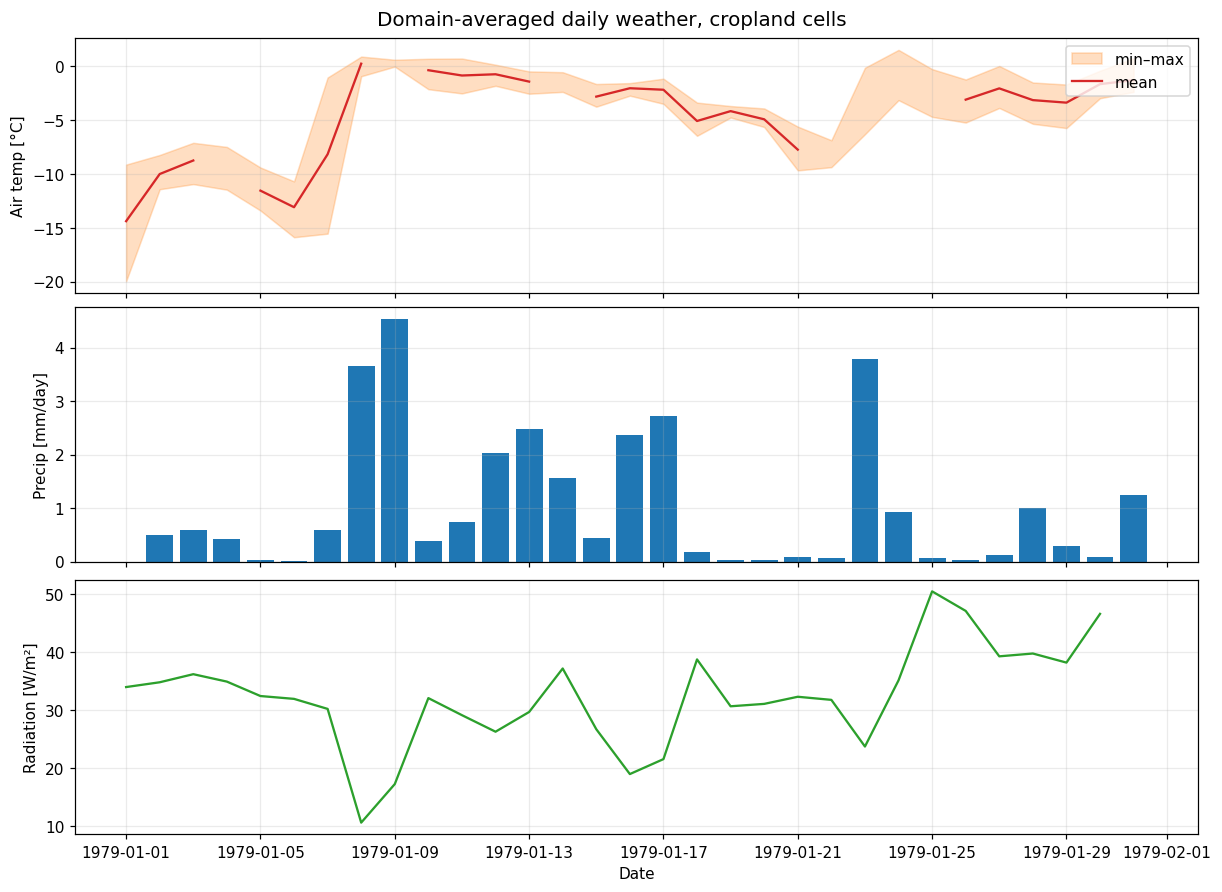

In [12]:
daily = wx.groupby("Date").agg(
    Tmin=("TempMin", "mean"), Tmean=("TempMean", "mean"), Tmax=("TempMax", "mean"),
    Precip=("Precipitation", "mean"), Rad=("Radiation", "mean"))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].fill_between(daily.index, daily.Tmin, daily.Tmax, alpha=0.25, color="tab:orange", label="min–max")
axes[0].plot(daily.index, daily.Tmean, color="tab:red", label="mean")
axes[0].set_ylabel("Air temp [°C]"); axes[0].legend(loc="upper right")
axes[1].bar(daily.index, daily.Precip, color="tab:blue", width=0.8)
axes[1].set_ylabel("Precip [mm/day]")
axes[2].plot(daily.index, daily.Rad, color="tab:green")
axes[2].set_ylabel("Radiation [W/m²]"); axes[2].set_xlabel("Date")
fig.suptitle("Domain-averaged daily weather, cropland cells", fontsize=13)
plt.show()

### 3.3 Spatial maps — monthly mean temperature & total precipitation

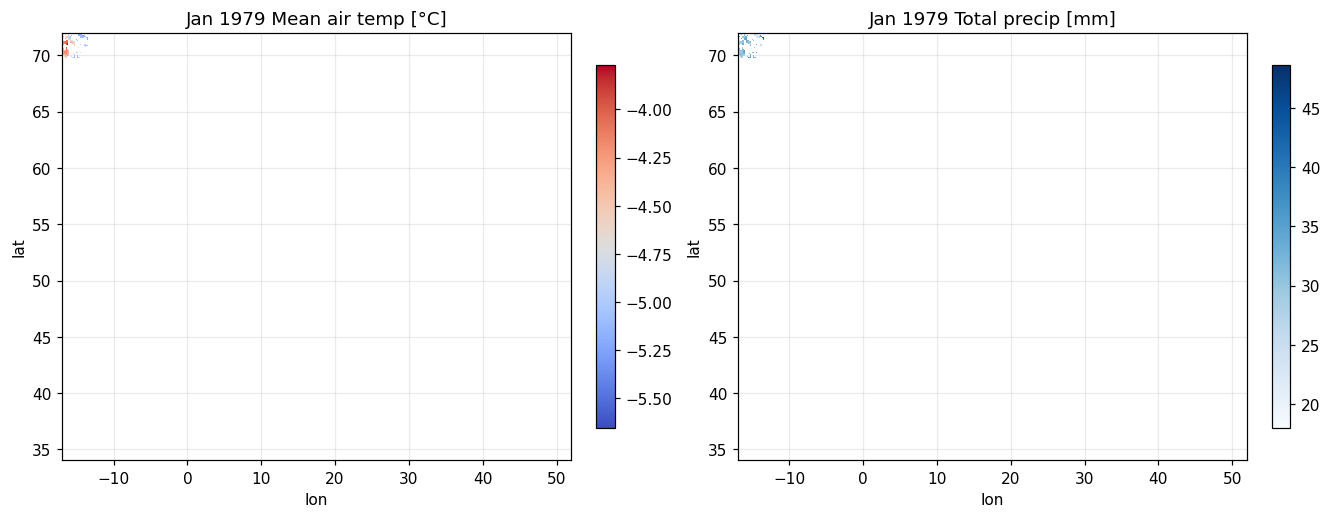

In [13]:
agg = wx.groupby(["row", "col"]).agg(
    Tmean=("TempMean", "mean"), Ptot=("Precipitation", "sum")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ax, (var, title, cmap) in zip(
        axes, [("Tmean", "Mean air temp [°C]", "coolwarm"),
               ("Ptot", "Total precip [mm]", "Blues")]):
    im = ax.imshow(grid_image(agg, var), extent=extent, origin="upper",
                   cmap=cmap, aspect="auto")
    ax.set_title(f"Jan 1979 {title}"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 4. Cross-check: soil & weather share the same cropland cells

Both stages consume the same masked cell table, so the exported soil `location`
IDs and the weather grid cells must reference the same set of grid cells.

In [14]:
soil_cells = set(soil["location"].astype(int))
wx_cells = set(cells.merge(wx[["row", "col"]].drop_duplicates(),
                           on=["row", "col"])["SimplaceID"].astype(int))
print("soil cells:", len(soil_cells), "| weather cells:", len(wx_cells))
print("identical cell set:", soil_cells == wx_cells)
print("soil-only:", len(soil_cells - wx_cells), "| weather-only:", len(wx_cells - soil_cells))

soil cells: 504 | weather cells: 504
identical cell set: False
soil-only: 474 | weather-only: 474


## 5. Summary

| Check | Result |
| --- | --- |
| Soil cells exported | see §2.1 (cropland-masked subset) |
| Texture normalized (clay+sand ≤ 100, silt ≥ 0) | §2.4 |
| No unfilled soil cells (gap-fill on) | §2.1 valid % |
| SOC / pH stratify by dominant soil class | §2.6 |
| Weather cells match soil cells | §4 |
| Weather variables provided vs. -99.9 | §3.1 |

`Windspeed`, `RefET`, `RelHumCalc` are `-99.9` because this config maps only
TAS/TASMIN/TASMAX/PR/RSDS/HURS — expected, not a defect. Everything else is
populated from the MSWX + SoilGrids dominant-soil-type pipeline.